In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### EDA

In [2]:
df = pd.read_csv('diabetes.csv') # Loading data set 

In [3]:
df.head() # print top 5 rows from the data set

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
rows , columns = df.shape # print the total rows and column inside the data set 
print('Total rows is :- ',rows,'Total columns is :- ',columns)
print('Total elements in the data :-',df.size) # print the total element in the data set 

Total rows is :-  768 Total columns is :-  9
Total elements in the data :- 6912


In [5]:
df.info() # print the summary of the data set 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [6]:
df.duplicated().sum() # Checks the duplicates in the data set 

np.int64(0)

In [7]:
# there is no duplicate values in the data or we can say entry

In [8]:
# checking null
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [9]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [10]:
# null values saying no missing value in the data but there are some entries with '0' which cannot possible in the medical data set so checking every 
# uniques values in the every columns for the better conclusion
all_col = df.select_dtypes(include=['int','float']).columns

for col in all_col:
    print(f'Unique values in {col}')
    print(df[col].unique())
    print('-'*50)

Unique values in Pregnancies
[ 6  1  8  0  5  3 10  2  4  7  9 11 13 15 17 12 14]
--------------------------------------------------
Unique values in Glucose
[148  85 183  89 137 116  78 115 197 125 110 168 139 189 166 100 118 107
 103 126  99 196 119 143 147  97 145 117 109 158  88  92 122 138 102  90
 111 180 133 106 171 159 146  71 105 101 176 150  73 187  84  44 141 114
  95 129  79   0  62 131 112 113  74  83 136  80 123  81 134 142 144  93
 163 151  96 155  76 160 124 162 132 120 173 170 128 108 154  57 156 153
 188 152 104  87  75 179 130 194 181 135 184 140 177 164  91 165  86 193
 191 161 167  77 182 157 178  61  98 127  82  72 172  94 175 195  68 186
 198 121  67 174 199  56 169 149  65 190]
--------------------------------------------------
Unique values in BloodPressure
[ 72  66  64  40  74  50   0  70  96  92  80  60  84  30  88  90  94  76
  82  75  58  78  68 110  56  62  85  86  48  44  65 108  55 122  54  52
  98 104  95  46 102 100  61  24  38 106 114]
---------------

In [11]:
# These are the some columns contain the value stored as '0' :-
# Pregnancies
# Glucose
# BloodPressure
# SkinThickness
# Insulin
# Outcome

# But these are the only possible column which cannot contain '0' as a value

In [12]:
# replacing '0' with nan
rep_col = ['Glucose','BloodPressure','SkinThickness','Insulin','BMI'] # these are the only possible column which cannot contain '0' as a value
df[rep_col] = df[rep_col].replace(0,np.nan)

In [13]:
# checking null values now
df.isnull().sum()

Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

In [14]:
# replacing the null values with there appropriate values
df.fillna(df.median(numeric_only=True),inplace=True)

In [15]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [16]:
num_col_1 = len(df.select_dtypes(include=['int']).columns)
int_col = df.select_dtypes(include=['int']).columns

num_col_2 = len(df.select_dtypes(include=['float']).columns)
float_col = df.select_dtypes(include=['float']).columns

num_col = df.select_dtypes(include = ['int','float']).columns

print('Total integer column :-', num_col_1)
print(int_col)
print()
print('Total float column :- ', num_col_2)
print(float_col)

Total integer column :- 3
Index(['Pregnancies', 'Age', 'Outcome'], dtype='object')

Total float column :-  6
Index(['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI',
       'DiabetesPedigreeFunction'],
      dtype='object')


### Statistical summary

In [17]:
# Descide is the inbuilt function in the padas which give the statistical summary of the data but only for the numerical columns

In [18]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.656250,72.386719,29.108073,140.671875,32.455208,0.471876,33.240885,0.348958
std,3.369578,30.438286,12.096642,8.791221,86.383060,6.875177,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,25.000000,121.500000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,29.000000,125.000000,32.300000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


### Spliting features and target

In [19]:
target = df[['Outcome']]
features = df.drop(columns = ['Outcome'])

In [20]:
target.head()

,Outcome
0,1
1,0
2,1
3,0
4,1


In [21]:
features.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6,148.0,72.0,35.0,125.0,33.6,0.627,50
1,1,85.0,66.0,29.0,125.0,26.6,0.351,31
2,8,183.0,64.0,29.0,125.0,23.3,0.672,32
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33


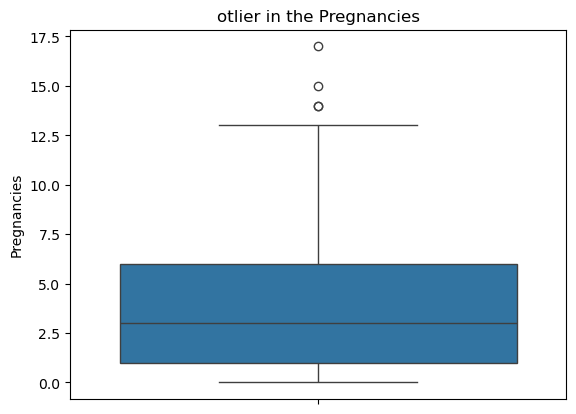

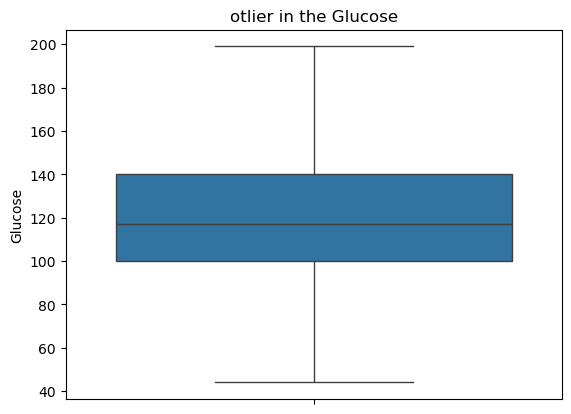

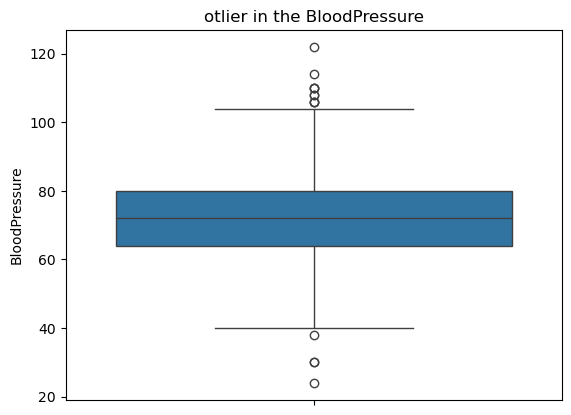

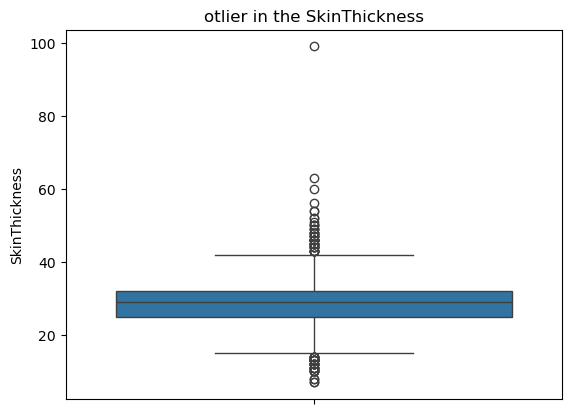

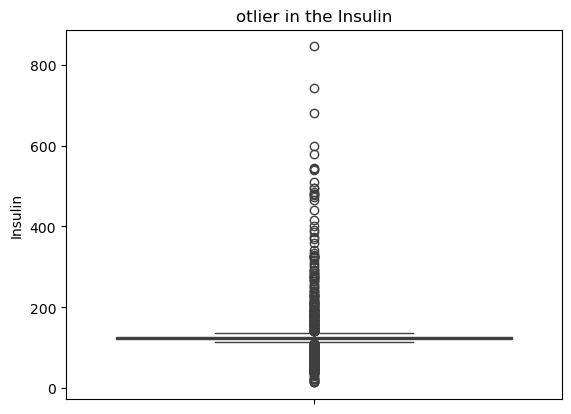

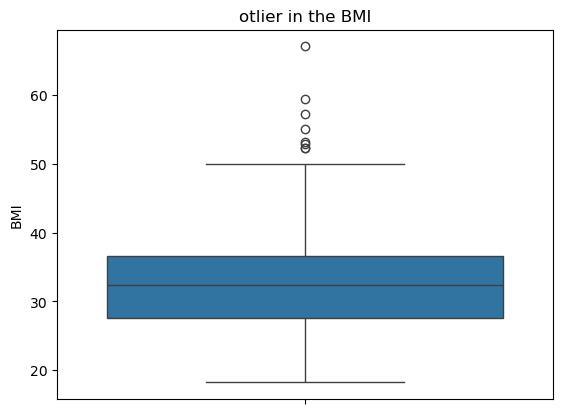

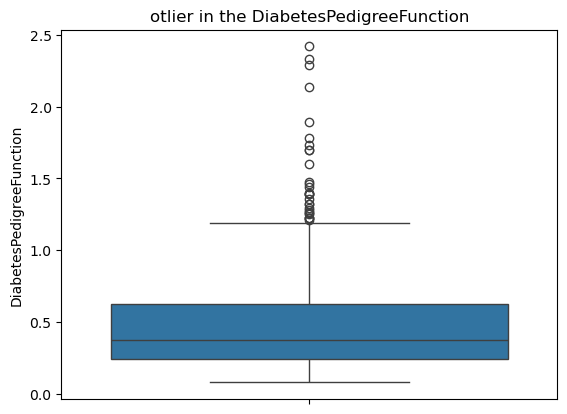

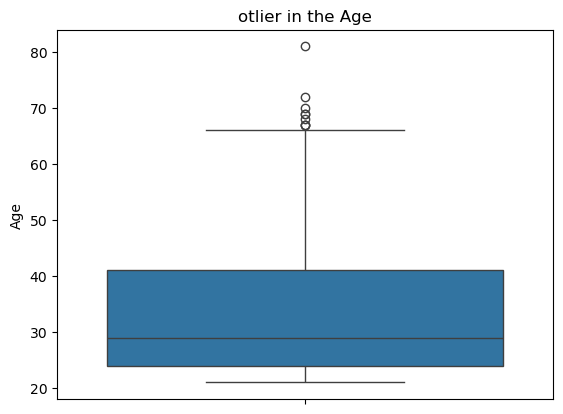

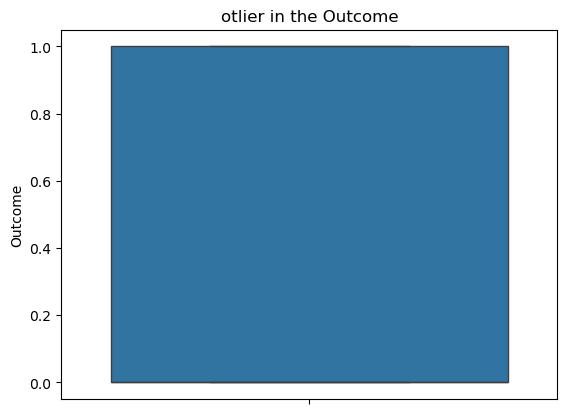

In [22]:
# outlier 
for col in num_col:
    plt.figure()
    sns.boxplot(data = df[col])
    plt.title(f'otlier in the {col}')
    plt.show()

In [23]:
# outlier capping
def outlier_capping(df,column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_extreme = Q1 - 1.5*IQR
    upper_extreme = Q3 + 1.5*IQR
    df[column] = df[column].apply(
        lambda x : lower_extreme if x < lower_extreme else upper_extreme if x > upper_extreme else x
    )
for col in features.select_dtypes(include=['int','float']).columns:
    outlier_capping(features,col)

<Axes: >

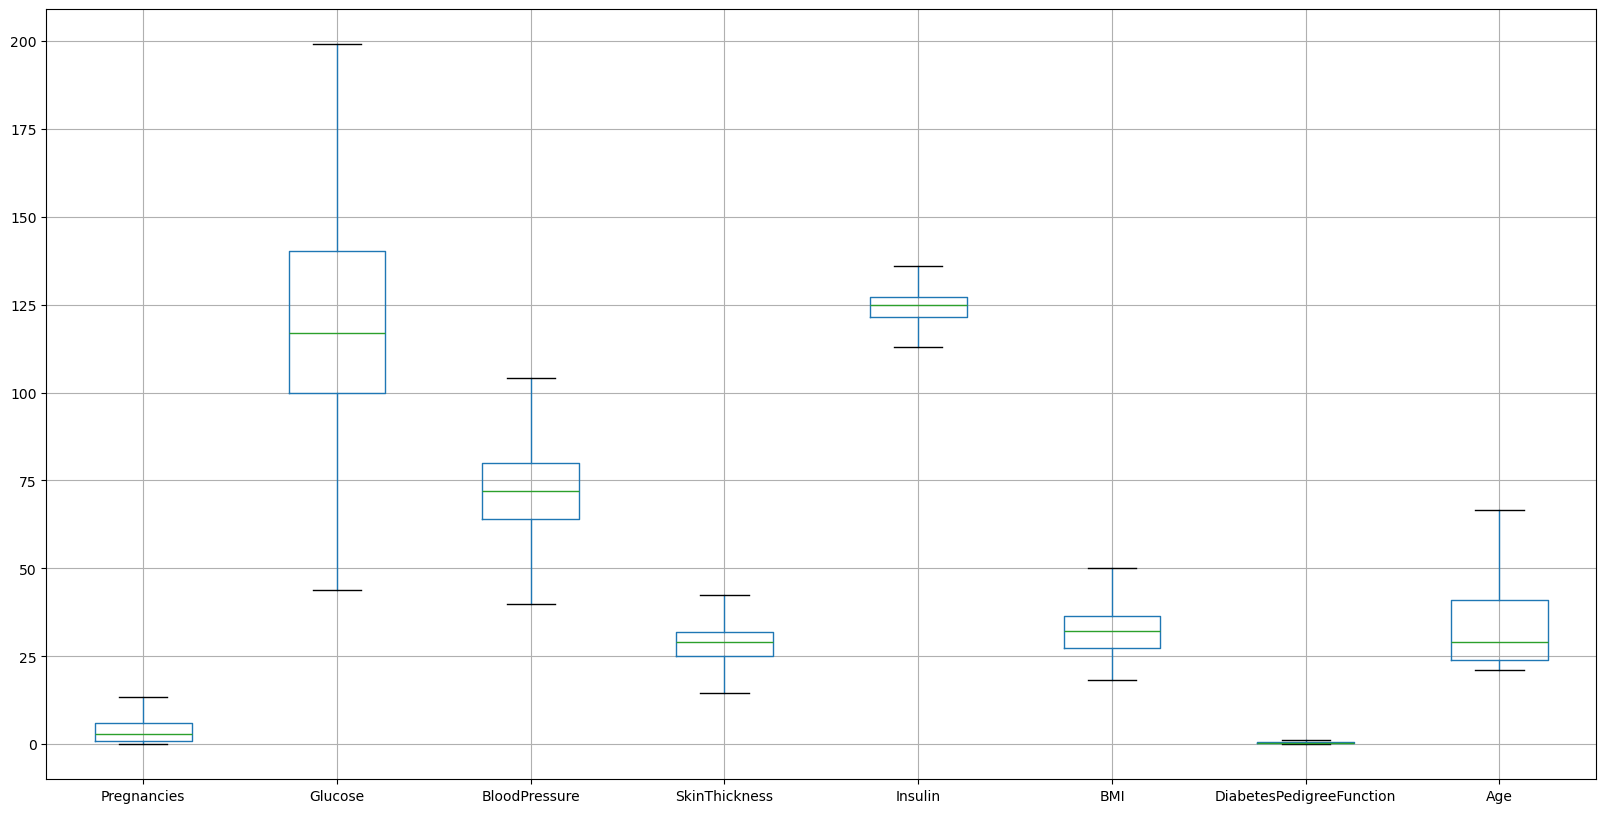

In [24]:
plt.figure(figsize=(20,10))
features.boxplot()

### Histogram

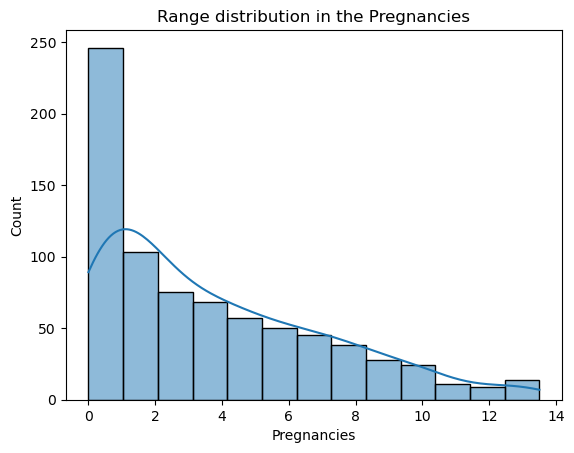

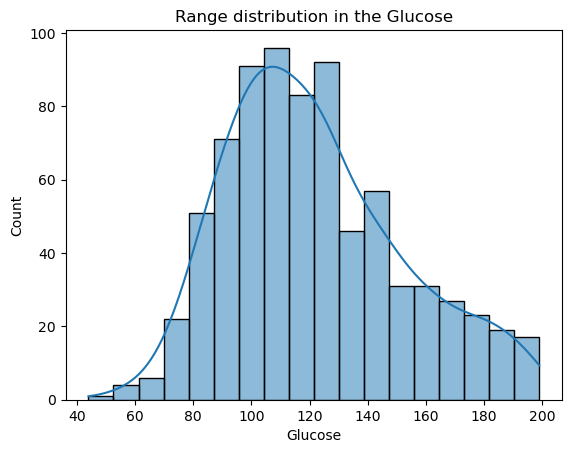

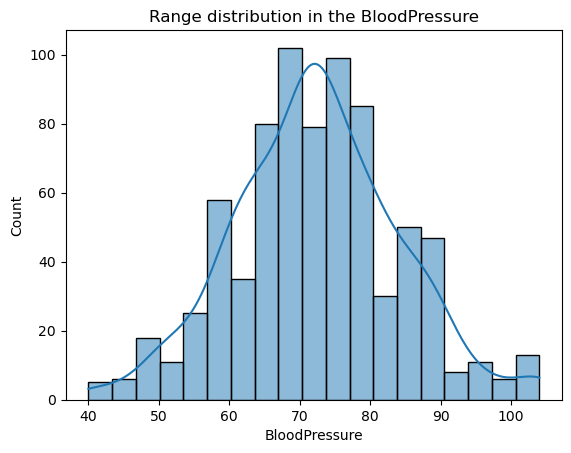

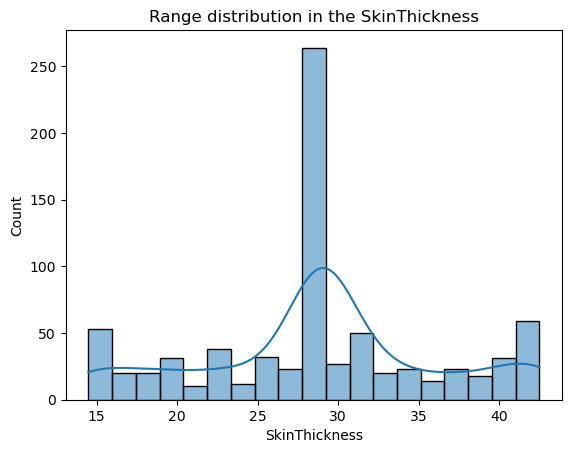

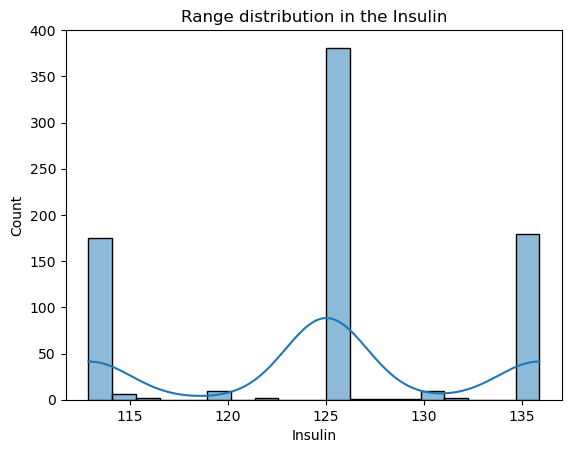

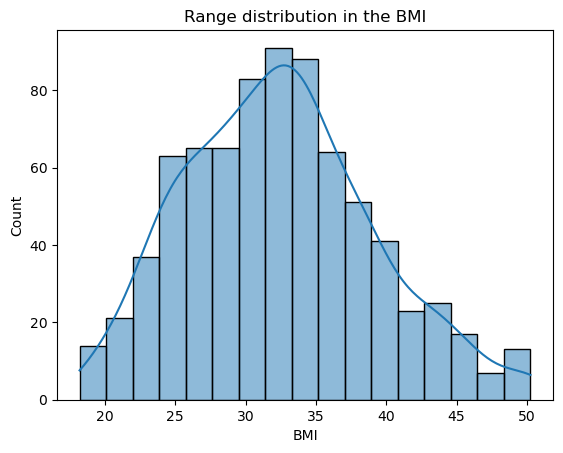

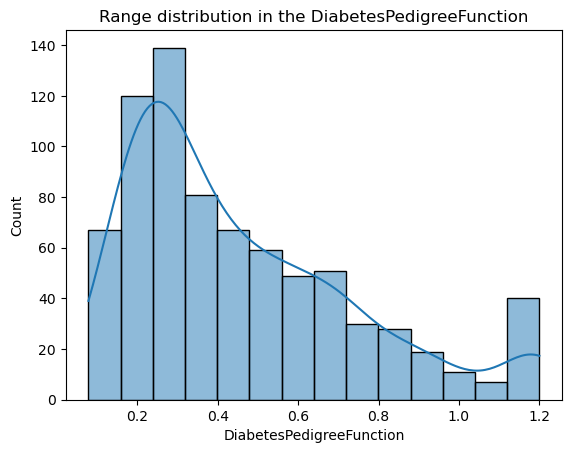

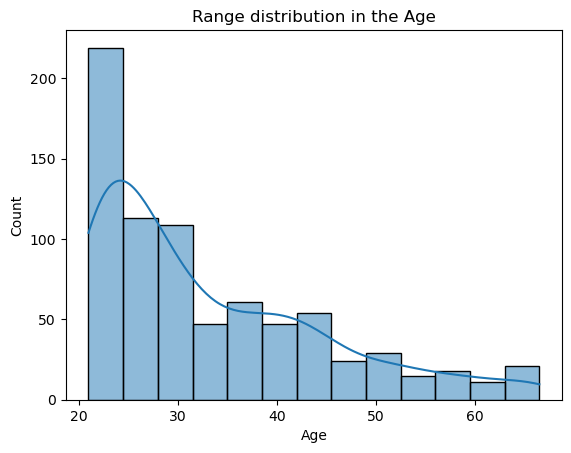

In [25]:
for col in features.select_dtypes(include=['int','float']).columns:
    plt.figure()
    sns.histplot(data = features[col],kde=True)
    plt.title(f'Range distribution in the {col}')
    plt.show()

In [29]:
# Positive skweness columns:- Pregnancies,Glucose,BMI,DiabetesPedigreeFunction,Age
import warnings
warnings.filterwarnings('ignore')

In [37]:
positive_skew = []
negative_skew = []
normal_skew = []

def skewness(df, column):
    mean = df[column].mean()
    median = df[column].median()
    std = df[column].std()

    if std == 0:
        return 0

    return (3 * (mean - median)) / std


for col in features.select_dtypes(include=['int', 'float']).columns:
    a = skewness(features, col)

    if a > 0:
        positive_skew.append((col, a))
    elif a < 0:
        negative_skew.append((col, a))
    else:
        normal_skew.append((col, a))

print("Positive skew:", positive_skew)
print("Negative skew:", negative_skew)
print("Normal skew:", normal_skew)

Positive skew: [('Pregnancies', np.float64(0.7510768974330126)), ('Glucose', np.float64(0.4589203899817913)), ('BloodPressure', np.float64(0.09183635655421706)), ('BMI', np.float64(0.04200664997074333)), ('DiabetesPedigreeFunction', np.float64(0.9077224407232305)), ('Age', np.float64(1.083520097263125))]
Negative skew: [('SkinThickness', np.float64(-0.053798929683658785)), ('Insulin', np.float64(-0.1171095820044433))]
Normal skew: []


In [42]:
# for target column
b = skewness(target,'Outcome')
print(b)
# target is also come in the positive skew category 

2.194930238071369


<Figure size 1000x500 with 0 Axes>

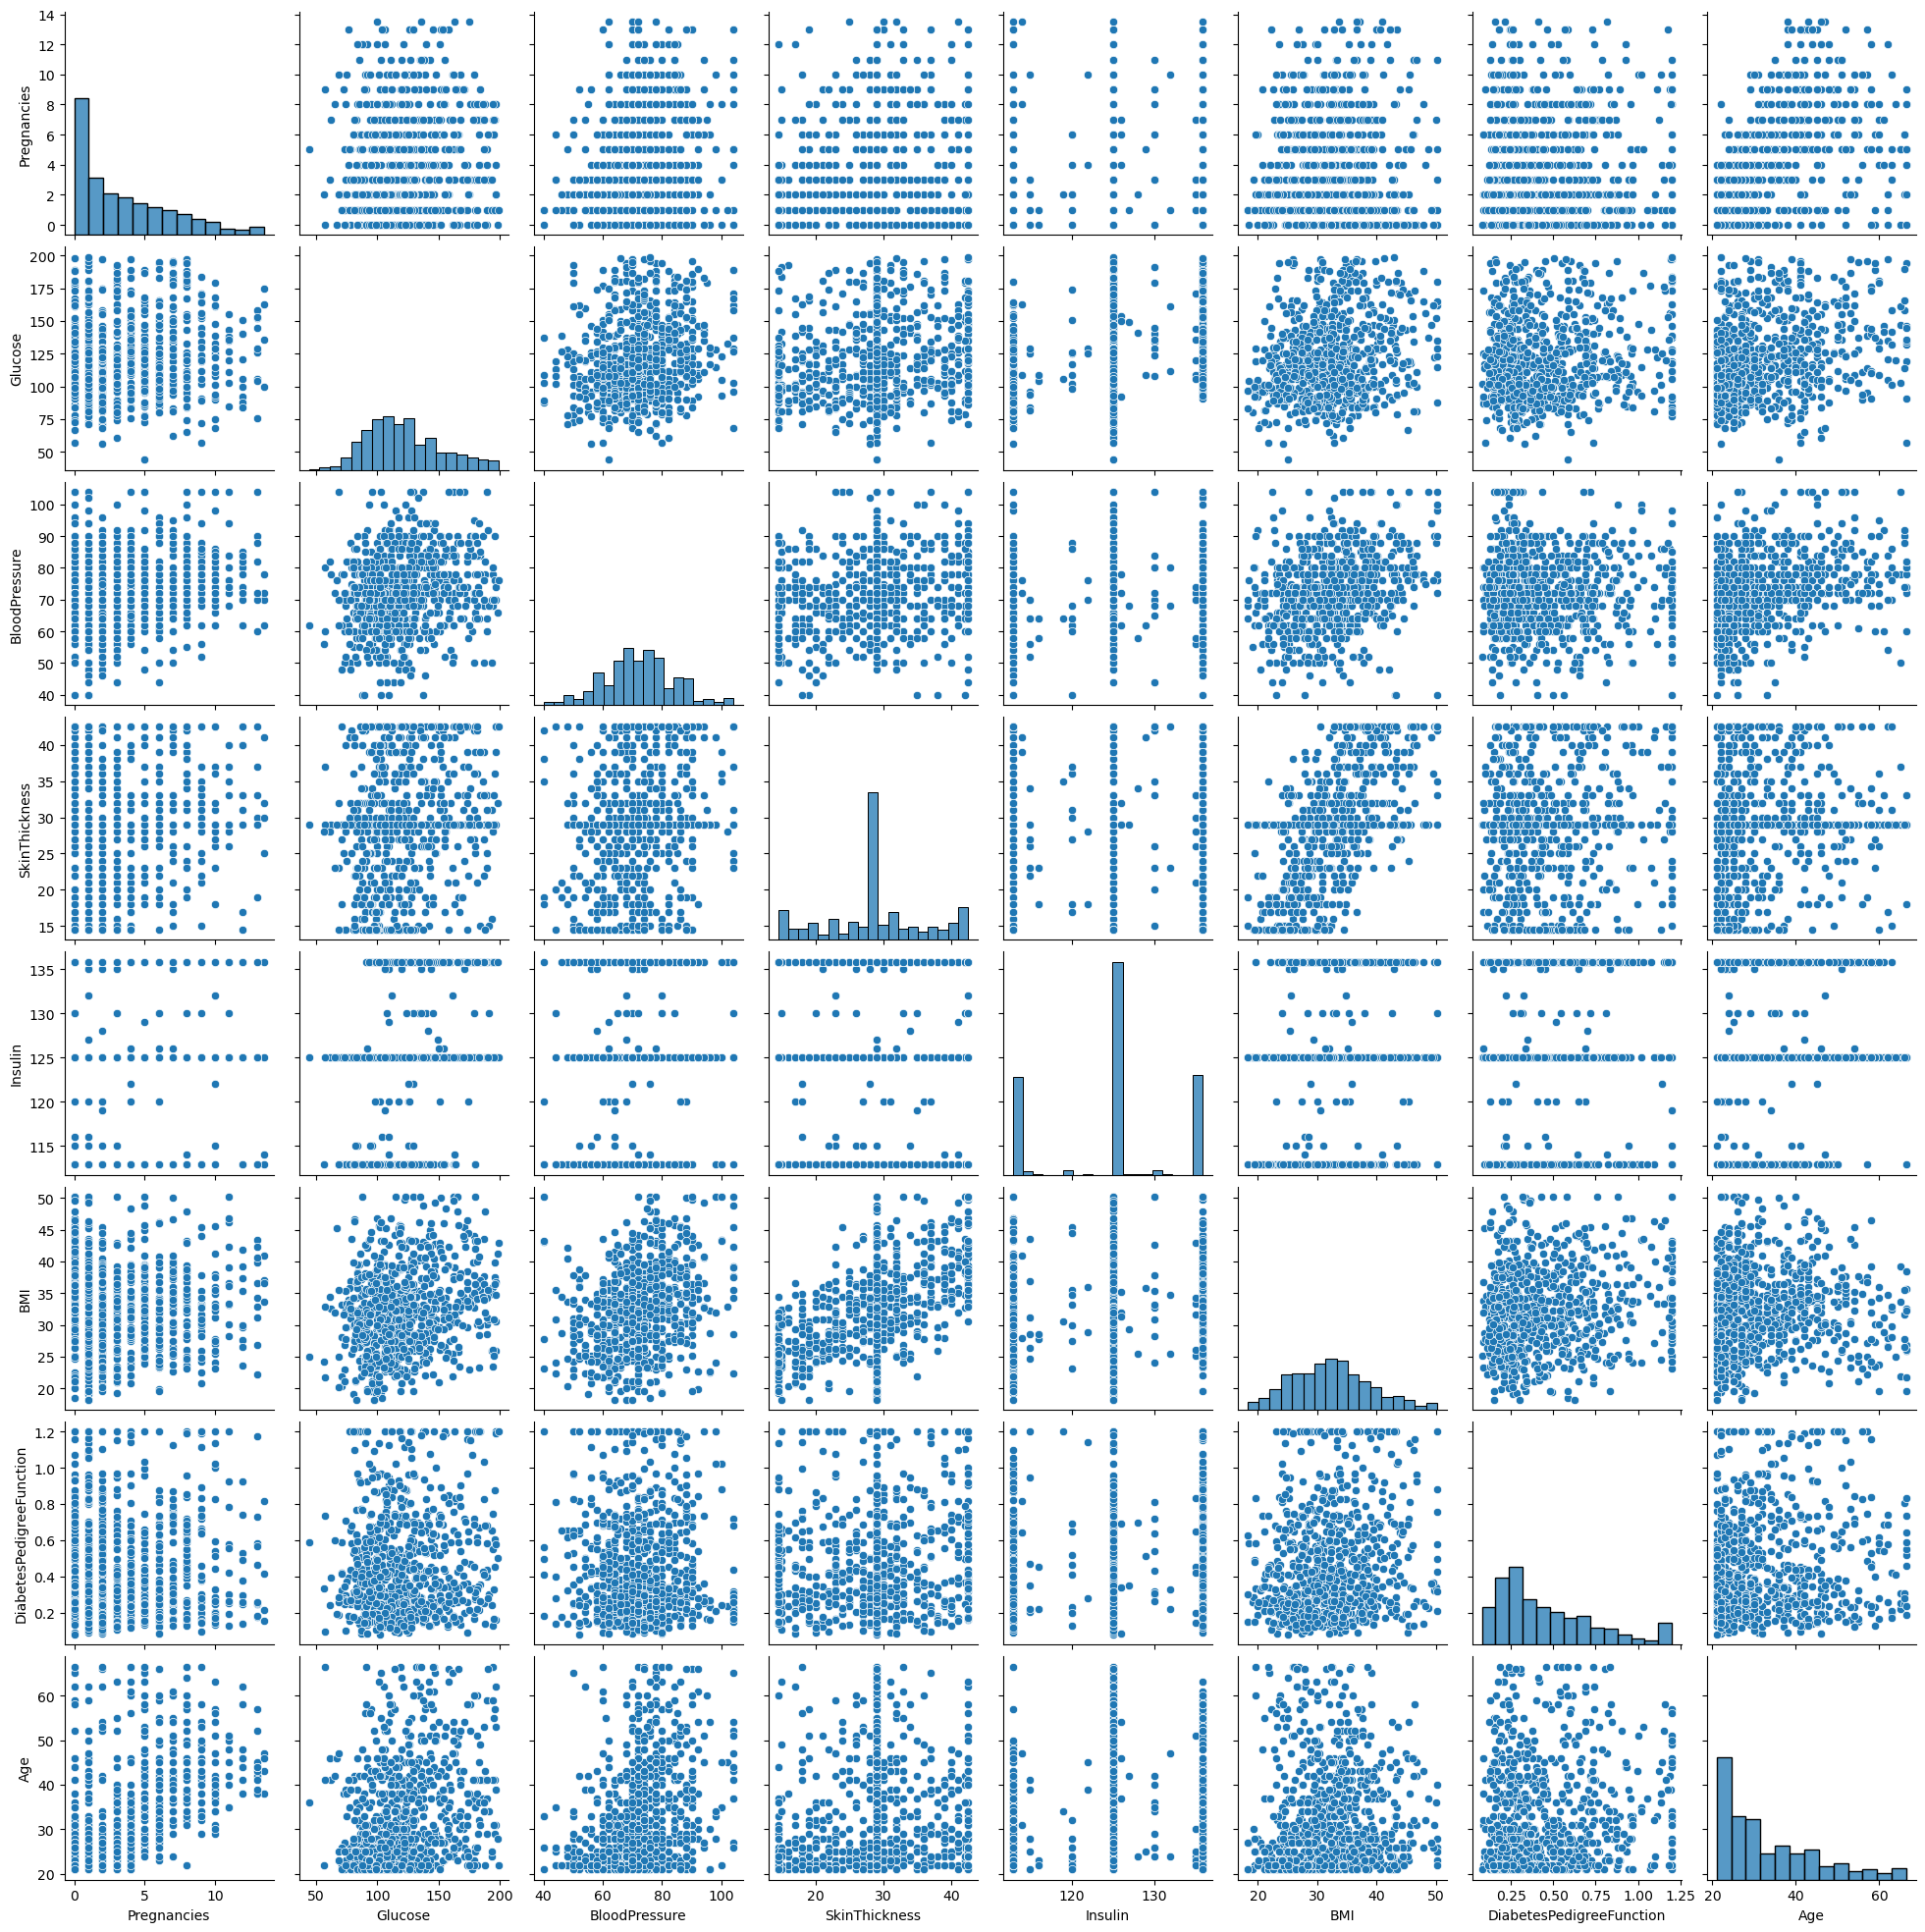

In [44]:
plt.figure(figsize=(10,5))
sns.pairplot(features)   
plt.show()           

### Feature Selection

In [45]:
from sklearn.feature_selection import f_classif
import warnings
warnings.filterwarnings('ignore')

<Axes: >

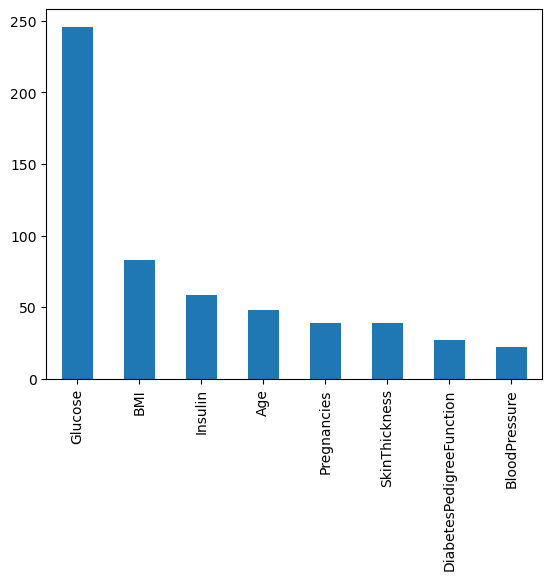

In [46]:
# using f_classif because the target column is Discrete
f_class = f_classif(features,target)
pd.Series(f_class[0],index = features.columns).sort_values(ascending = False).plot(kind = 'bar')

In [47]:
# so not droping any columns from the feature because we have less columns and there f_score is not bad also 

In [48]:
# checking multicolinearity
from statsmodels.stats.outliers_influence import variance_inflation_factor
VIF = pd.DataFrame()
VIF['FEATURES'] = features.columns
VIF['VIF_SCORE'] = [variance_inflation_factor(features.values,i)for i in range(len(features.columns))]
VIF

,FEATURES,VIF_SCORE
0,Pregnancies,3.340656
1,Glucose,21.481907
2,BloodPressure,45.140405
3,SkinThickness,24.084400
4,Insulin,61.175356
5,BMI,39.414907
6,DiabetesPedigreeFunction,3.708540
7,Age,14.987236


In [49]:
# we have some very high multicolinearity in columns like :-
# 1. Glucose
# 2. BloodPressure
# 3. SkinThickness
# 4. Insulin
# 5. BMI
# 6. Age

# normaly when the vif_score > 10 then it is considere as multicolinearity 
# but as there are only '8' columns in the data so we can not delete any column, also in logistic regression multicolinearity doesn't affect that much
# jus like the regression ones 

### Train_Sest-Split

In [50]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(features,target,train_size=0.8,random_state=100)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(614, 8)
(154, 8)
(614, 1)
(154, 1)


In [51]:
x_train.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
660,10.0,162.0,84.0,29.0,125.000,27.7,0.182,54.0
69,4.0,146.0,85.0,27.0,112.875,28.9,0.189,27.0
85,2.0,110.0,74.0,29.0,125.000,32.4,0.698,27.0
219,5.0,112.0,66.0,29.0,125.000,37.8,0.261,41.0
712,10.0,129.0,62.0,36.0,125.000,41.2,0.441,38.0


In [52]:
# doing scaling
from sklearn.preprocessing import StandardScaler
std_scale = StandardScaler()

In [53]:
x_col = x_train.columns
x_col

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age'],
      dtype='object')

In [54]:
x_train[x_col] = std_scale.fit_transform(x_train[x_col])
x_test[x_col] = std_scale.fit_transform(x_test[x_col])

### Model training

In [55]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix,classification_report,accuracy_score,log_loss

In [56]:
# model training
log_reg = LogisticRegression()
log_reg.fit(x_train,y_train)
# prediction from the model while training
y_pred = log_reg.predict(x_train)
# accuracy form the model while training
train_acc = accuracy_score(y_train,y_pred)
# prediction from the model while testing
y_pred1 = log_reg.predict(x_test)
test_acc = accuracy_score(y_test,y_pred1)

print('Training_accuracy :-',train_acc)
print('Testing_accuracy :-',test_acc)

Training_accuracy :- 0.7833876221498371
Testing_accuracy :- 0.7337662337662337


### confusion_matrix

Text(0.5, 1.0, 'Confusion_matrix')

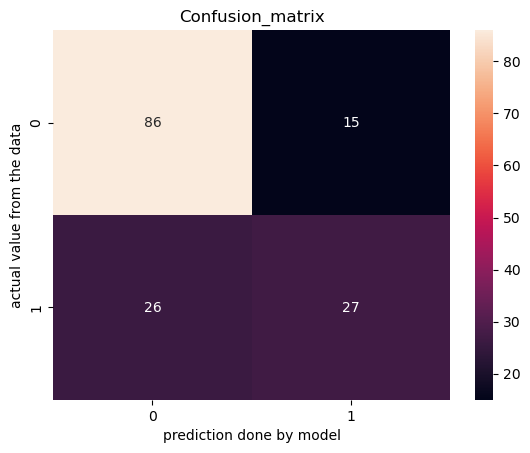

In [57]:
conf = confusion_matrix(y_test,y_pred1)
sns.heatmap(data = conf,annot = True)
plt.xlabel('prediction done by model')
plt.ylabel('actual value from the data')
plt.title('Confusion_matrix')

In [58]:
type_error_1 = 15 # false negative
type_error_2 = 26 # false postive

### Classification Report 

In [59]:
print(classification_report(y_test,y_pred1))

              precision    recall  f1-score   support

           0       0.77      0.85      0.81       101
           1       0.64      0.51      0.57        53

    accuracy                           0.73       154
   macro avg       0.71      0.68      0.69       154
weighted avg       0.72      0.73      0.73       154



In [60]:
print('B_node :- ',log_reg.intercept_)
print('Coefficient :-', log_reg.coef_)

B_node :-  [-0.9161647]
Coefficient :- [[0.34903677 1.13238561 0.00620386 0.07863606 0.19306961 0.55634706
  0.43259451 0.188387  ]]


### error

In [61]:
# log_loss
sigmoid = log_reg.predict_proba(x_test)[:,1]
log_loss(y_test,sigmoid)

0.5570901830829283

### Roc_curve

In [62]:
from sklearn.metrics import roc_auc_score,roc_curve
auc_score = roc_auc_score(y_test,sigmoid)

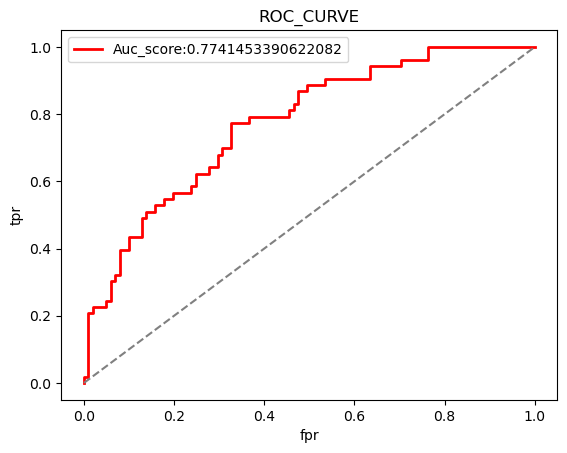

In [63]:
fpr,tpr,thr =roc_curve(y_test,sigmoid)
plt.plot(fpr,tpr,color = 'red',lw =2 ,label = f'Auc_score:{auc_score}')
plt.plot([0,1],linestyle = '--',color = 'grey')
plt.xlabel('fpr')
plt.ylabel('tpr')
plt.title('ROC_CURVE')
plt.legend()
plt.show()

In [64]:
# Roc is cover 0.77 whcih is a very good sign 
# Model is performing very well in training as well as the testing 

### for deployement

In [65]:
import pickle

In [66]:
file = 'log11.pkl'

In [67]:
pickle.dump(log_reg,open(file,'wb'))
# wb stands for write byte

In [68]:
file1 = 'std_sca11.pkl'

In [69]:
pickle.dump(std_scale,open(file1,'wb'))

### Assignment 